In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import mode

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.simplefilter(action="ignore", category=FutureWarning)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)
import seaborn as sns

In [2]:
# Load Dataset
# Load dataset
df = pd.read_csv("drug_addiction.csv")  
print("Columns:", df.columns.tolist())

df.head()

Columns: ['Age', 'Gender', 'Family History of Addiction', 'Mental Health Issues', 'Past Drug Use', 'Peer Pressure', 'Stress or Trauma', 'Social Isolation', 'How Often They Use Drugs', 'Work or School Problems', 'Health Problems', 'Access to Drugs', 'Why They Use Drugs', 'Trying to Quit', 'Addicted (Yes/No)']


,Age,Gender,Family History of Addiction,Mental Health Issues,Past Drug Use,Peer Pressure,Stress or Trauma,Social Isolation,How Often They Use Drugs,Work or School Problems,Health Problems,Access to Drugs,Why They Use Drugs,Trying to Quit,Addicted (Yes/No)
0,41,Male,Yes,No,No,No,No,Yes,Daily,Poor,No,Easy,Other,Yes,No
1,54,Female,Yes,Yes,Yes,Yes,Yes,Yes,Occasionally,Poor,Yes,Hard,Stress Relief,No,Yes
2,49,Female,No,No,Yes,Yes,No,No,Rarely,Excellent,No,Hard,Stress Relief,Yes,No
3,54,Female,No,No,No,Yes,Yes,No,Daily,Excellent,Yes,Easy,No Motivation,No,No
4,60,Female,Yes,Yes,Yes,Yes,No,Yes,Occasionally,Average,Yes,Hard,No Motivation,Yes,No


In [3]:
# Clean Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={"addicted_(yes/no)": "drug_addiction"}, inplace=True)

df.head()

,age,gender,family_history_of_addiction,mental_health_issues,past_drug_use,peer_pressure,stress_or_trauma,social_isolation,how_often_they_use_drugs,work_or_school_problems,health_problems,access_to_drugs,why_they_use_drugs,trying_to_quit,drug_addiction
0,41,Male,Yes,No,No,No,No,Yes,Daily,Poor,No,Easy,Other,Yes,No
1,54,Female,Yes,Yes,Yes,Yes,Yes,Yes,Occasionally,Poor,Yes,Hard,Stress Relief,No,Yes
2,49,Female,No,No,Yes,Yes,No,No,Rarely,Excellent,No,Hard,Stress Relief,Yes,No
3,54,Female,No,No,No,Yes,Yes,No,Daily,Excellent,Yes,Easy,No Motivation,No,No
4,60,Female,Yes,Yes,Yes,Yes,No,Yes,Occasionally,Average,Yes,Hard,No Motivation,Yes,No


In [4]:
# Handle Missing Values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

age                            0
gender                         0
family_history_of_addiction    0
mental_health_issues           0
past_drug_use                  0
peer_pressure                  0
stress_or_trauma               0
social_isolation               0
how_often_they_use_drugs       0
work_or_school_problems        0
health_problems                0
access_to_drugs                0
why_they_use_drugs             0
trying_to_quit                 0
drug_addiction                 0
dtype: int64

In [5]:
# Encode Target Column
df["drug_addiction"] = df["drug_addiction"].map({"Yes": 1, "No": 0})
df["drug_addiction"].value_counts()

drug_addiction
0    573
1    427
Name: count, dtype: int64

In [6]:
# Encode Categorical Features
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Save encoders
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("✅ Label encoders saved.")
df.head()

✅ Label encoders saved.


,age,gender,family_history_of_addiction,mental_health_issues,past_drug_use,peer_pressure,stress_or_trauma,social_isolation,how_often_they_use_drugs,work_or_school_problems,health_problems,access_to_drugs,why_they_use_drugs,trying_to_quit,drug_addiction
0,41,1,1,0,0,0,0,1,0,2,0,0,3,1,0
1,54,0,1,1,1,1,1,1,1,2,1,1,4,0,1
2,49,0,0,0,1,1,0,0,2,1,0,1,4,1,0
3,54,0,0,0,0,1,1,0,0,1,1,0,2,0,0
4,60,0,1,1,1,1,0,1,1,0,1,1,2,1,0


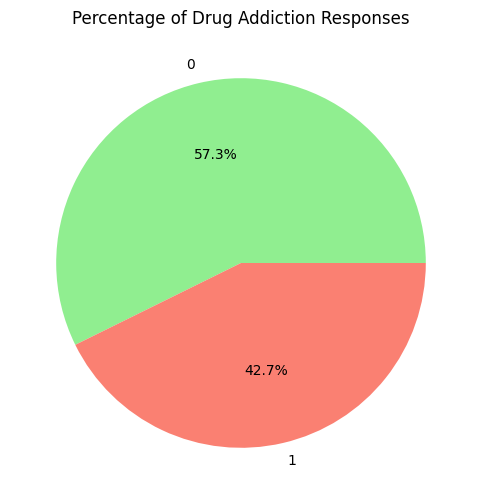

In [7]:
# Pie Chart Visualization
plt.figure(figsize=(6, 6))
df["drug_addiction"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["lightgreen", "salmon"]
)
plt.title("Percentage of Drug Addiction Responses")
plt.ylabel("")
plt.show()

In [8]:
# target variable
target = df['drug_addiction']

In [9]:
# Train-Test Split
X = df.drop(columns=["drug_addiction"])
y = df["drug_addiction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=target
)

In [ ]:
# Train Models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        val_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    results[name] = {"train": train_acc, "test": test_acc}
    
    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc:.2f}")
    print(f"Test  Accuracy: {test_acc:.2f}")


Decision Tree
Train Accuracy: 1.00
Test  Accuracy: 0.96

SVM
Train Accuracy: 0.57
Test  Accuracy: 0.57

Random Forest
Train Accuracy: 1.00
Test  Accuracy: 0.97

kNN
Train Accuracy: 0.86
Test  Accuracy: 0.73

XGBoost
Train Accuracy: 1.00
Test  Accuracy: 0.99
[LightGBM] [Info] Number of positive: 299, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 77
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.427143 -> initscore=-0.293518
[LightGBM] [Info] Start training from score -0.293518
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

C:\Users\ZAHID HASAN\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [08:46:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "val_metric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


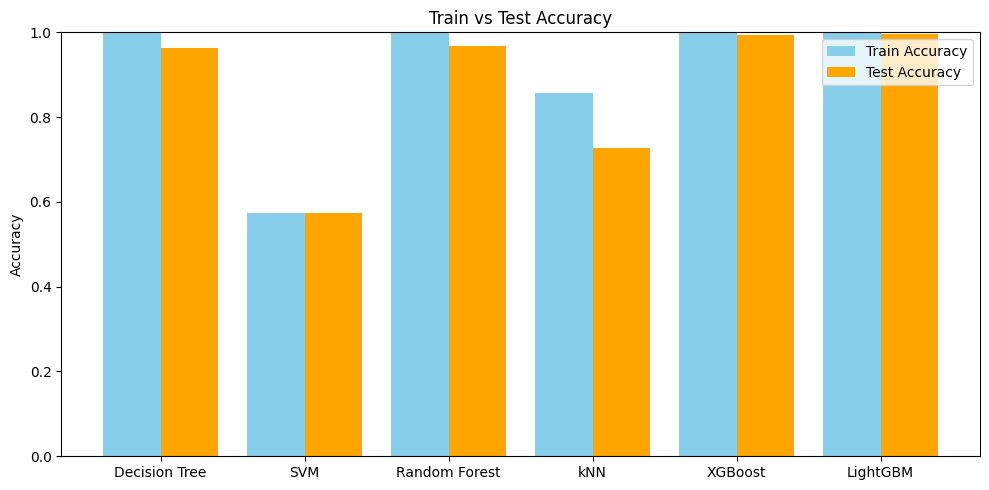

In [11]:
# Accuracy Comparison Chart
model_names = list(results.keys())
train_accuracies = [results[m]["train"] for m in model_names]
test_accuracies = [results[m]["test"] for m in model_names]

x = np.arange(len(model_names))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, train_accuracies, 0.4, label='Train Accuracy', color='skyblue')
plt.bar(x + 0.2, test_accuracies, 0.4, label='Test Accuracy', color='orange')

plt.xticks(x, model_names)
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Save Best Model
best_model_name, best_result = max(results.items(), key=lambda x: x[1]['test'])
best_model = models[best_model_name]

print(f"✅ Best Model: {best_model_name}")
print(f"Test Accuracy: {best_result['test']:.2f}")

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ Best model saved.")

✅ Best Model: LightGBM
Test Accuracy: 1.00
✅ Best model saved.


In [13]:
# KMeans Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

def map_cluster_to_label(kmeans_labels, true_labels):
    labels = np.zeros_like(kmeans_labels)
    for i in range(2):
        mask = (kmeans_labels == i)
        labels[mask] = mode(true_labels[mask], keepdims=True)[0]
    return labels

mapped_preds = map_cluster_to_label(
    df["cluster"].values,
    df["drug_addiction"].values
)

kmeans_acc = accuracy_score(df["drug_addiction"], mapped_preds)
print(f"K-Means Accuracy (approx): {kmeans_acc:.2f}")

K-Means Accuracy (approx): 0.57


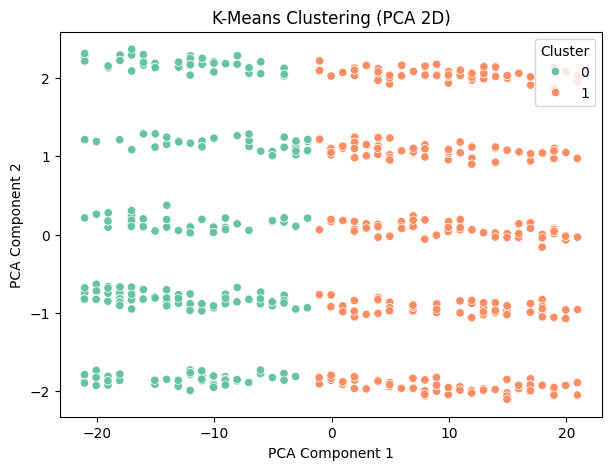

In [14]:
# PCA Visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=df['cluster'],
    palette='Set2'
)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

In [15]:
# Make Predictions (Test Set)
y_pred = best_model.predict(X_test)

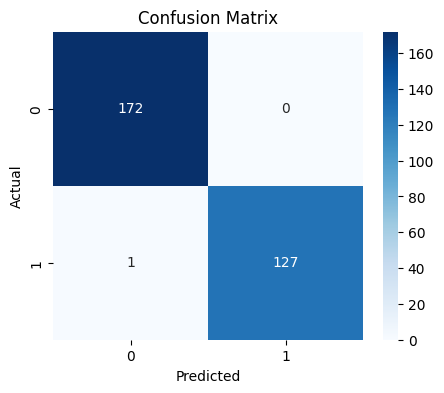

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
# Classification Report + F1 Score
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred)
print("F1 Score:", round(f1, 2))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       172
           1       1.00      0.99      1.00       128

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

F1 Score: 1.0


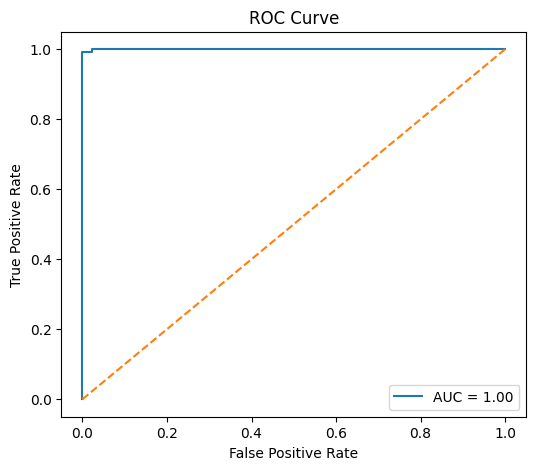

ROC-AUC Score: 1.0


In [18]:
# ROC Curve + AUC
# Probability predictions
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:,1]
else:
    y_prob = best_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", round(auc_score,2))